# U-Net과 CNN 모델 테스트 (파이프라인 방식)

이 노트북은 학습된 U-Net과 CNN 모델을 새로운 데이터로 테스트하는 데 사용됩니다.

## 테스트 프로세스

1. **U-Net 테스트**: 모든 이미지를 U-Net으로 테스트하여 결함을 검출합니다.
2. **결함 검출 필터링**: U-Net이 결함을 검출한 이미지만 선별합니다.
3. **CNN 테스트**: 선별된 이미지만 CNN으로 결함 유형을 분류합니다.

## 사용 방법

1. **Cell 3**에서 모델 경로와 테스트 데이터 경로를 설정합니다.
   - `UNET_MODEL_PATH`: U-Net 모델 파일 경로 (.h5)
   - `CNN_MODEL_PATH`: CNN 모델 파일 경로 (.pth)
   - `TEST_DATA_DIR`: 테스트할 데이터 디렉터리 경로

2. 셀을 순서대로 실행합니다.
   - Cell 1-2: 초기화 및 라이브러리 import
   - Cell 3-4: 설정 및 데이터 확인
   - Cell 5-6: 모델 로드
   - Cell 7: U-Net 테스트 실행 (결함 검출된 파일 리스트 생성)
   - Cell 8: CNN 테스트 실행 (U-Net이 검출한 이미지만 처리)
   - Cell 9-11: 결과 분석 및 저장

## 평가 지표

- **U-Net**: MeanIoU (Mean Intersection over Union) - Semantic Segmentation 정확도
- **CNN**: 정확도 (Accuracy) - 결함 패치 분류 정확도 (U-Net이 검출한 이미지만)

## 출력 결과

- 콘솔: 실시간 테스트 진행 상황 및 요약 결과
- 시각화: 성능 분포 및 상위 파일 그래프 (`test_results/` 폴더)
- JSON: 상세 결과 파일 (`test_results/test_results_summary.json`)


In [1]:
# Cell 1: 데이터 초기화 및 GPU 확인
import torch
import tensorflow as tf
import gc
import random
import numpy as np

# GPU 메모리 정리
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print("PyTorch GPU 메모리 정리 완료")

# TensorFlow GPU 메모리 설정
if tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
    print("TensorFlow GPU 메모리 설정 완료")

# Python 가비지 컬렉션
gc.collect()

# 재현성을 위한 시드 설정
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"랜덤 시드 설정 완료: {RANDOM_SEED}")

# GPU 확인
print('PyTorch GPU:', end=' ')
print('GPU not found.') if not torch.cuda.is_available() else print(f'Found GPU: {torch.cuda.get_device_name(0)}')

print('TensorFlow GPU:', end=' ')
device_name = tf.test.gpu_device_name()
print('GPU not found.') if device_name != '/device:GPU:0' else print(f'Found GPU at: {device_name}')


PyTorch GPU 메모리 정리 완료
랜덤 시드 설정 완료: 42
PyTorch GPU: Found GPU: NVIDIA GeForce RTX 3070
TensorFlow GPU: GPU not found.


In [2]:
# Cell 2: 라이브러리 import
import torch
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import defaultdict
import json
from scipy.ndimage import zoom

# U-Net 관련 import
from utils.u_net.image_processing import preprocess_image, unsplit_image, unsplit_image_mask
from utils.u_net.dataset_functions import create_dataset, unwrap_client_data

# CNN 관련 import
from utils.patch_cnn.classifier import load_defect_classifier
from utils.patch_cnn.dataset_functions import (
    load_image_for_patch, create_patches_adaptive_grid,
    get_albumentations_transform, get_defect_type_for_patch,
    get_label_mapping
)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 import 완료")


라이브러리 import 완료


In [3]:
# Cell 3: 설정 및 경로 지정

# ========== 모델 경로 설정 ==========
# U-Net 모델 경로 (.h5 파일)
UNET_MODEL_PATH = 'saved_models\FL_30_10_32_8e05_HoldoutPart1213.h5'

# CNN 모델 경로 (.pth 파일)
CNN_MODEL_PATH = 'saved_models/Defect_Classifier_FL_20_10_32_1e04.pth'

# ========== 테스트 데이터 경로 ==========
# 테스트할 데이터 디렉터리 (다른 데이터셋을 사용하려면 경로 변경)
TEST_DATA_DIR = 'data_test/'  # 또는 'data_train/' 등 다른 경로

# ========== 하이퍼파라미터 설정 ==========
UNET_TILE_SIZE = 128  # U-Net 타일 크기
CNN_PATCH_SIZE = (256, 256)  # CNN 패치 크기
MIN_CONFIDENCE = 0.3  # CNN 최소 신뢰도

# ========== 출력 디렉터리 ==========
OUTPUT_DIR = 'test_results'  # 결과 저장 디렉터리

print("=" * 80)
print("설정 완료")
print("=" * 80)
print(f"U-Net 모델 경로: {UNET_MODEL_PATH}")
print(f"CNN 모델 경로: {CNN_MODEL_PATH}")
print(f"테스트 데이터 디렉터리: {TEST_DATA_DIR}")
print(f"출력 디렉터리: {OUTPUT_DIR}")
print("=" * 80)


설정 완료
U-Net 모델 경로: saved_models\FL_30_10_32_8e05_HoldoutPart1213.h5
CNN 모델 경로: saved_models/Defect_Classifier_FL_20_10_32_1e04.pth
테스트 데이터 디렉터리: data_test/
출력 디렉터리: test_results


In [4]:
# Cell 4: 테스트 데이터 확인 및 파일 리스트 생성

test_path = Path(TEST_DATA_DIR)
image_path0 = test_path / '0'
image_path1 = test_path / '1'
annotations_path = test_path / 'annotations'

# 테스트 파일 찾기
test_files = []
if annotations_path.exists():
    test_files = sorted([f.stem for f in annotations_path.glob('*.npy')])

if len(test_files) == 0:
    print(f"경고: {TEST_DATA_DIR}에서 테스트 파일을 찾을 수 없습니다.")
else:
    print(f"테스트 파일 개수: {len(test_files)}개")
    print(f"처리할 파일 예시: {test_files[:5]}")
    if len(test_files) > 5:
        print(f"... 외 {len(test_files) - 5}개 파일")
    
    # 첫 번째 파일로 데이터 구조 확인
    if len(test_files) > 0:
        first_file = test_files[0]
        img0_path = image_path0 / f"{first_file}.jpg"
        img1_path = image_path1 / f"{first_file}.jpg"
        npy_path = annotations_path / f"{first_file}.npy"
        
        if img0_path.exists() and img1_path.exists() and npy_path.exists():
            im0 = Image.open(img0_path)
            mask = np.load(npy_path)
            print(f"\n첫 번째 파일 확인 ({first_file}):")
            print(f"  이미지 크기 (0): {im0.size}")
            print(f"  마스크 크기: {mask.shape}")
            print(f"  마스크 레이블 유형: {np.unique(mask)}")


테스트 파일 개수: 78개
처리할 파일 예시: ['000001', '000002', '000003', '000004', '000005']
... 외 73개 파일

첫 번째 파일 확인 (000001):
  이미지 크기 (0): (766, 766)
  마스크 크기: (766, 766)
  마스크 레이블 유형: [0 1 8]


In [5]:
# Cell 5: U-Net 모델 로드

print("=" * 80)
print("U-Net 모델 로드 중...")
print("=" * 80)

unet_model = None
if Path(UNET_MODEL_PATH).exists():
    try:
        unet_model = tf.keras.models.load_model(UNET_MODEL_PATH, compile=False)
        print(f"U-Net 모델 로드 완료: {UNET_MODEL_PATH}")
        
        # 모델 컴파일 (테스트를 위해)
        unet_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )
        print("모델 컴파일 완료")
    except Exception as e:
        print(f"U-Net 모델 로드 실패: {e}")
        unet_model = None
else:
    print(f"경고: U-Net 모델 파일을 찾을 수 없습니다: {UNET_MODEL_PATH}")

if unet_model is not None:
    print("\nU-Net 모델 요약:")
    unet_model.summary()


U-Net 모델 로드 중...
U-Net 모델 로드 완료: saved_models\FL_30_10_32_8e05_HoldoutPart1213.h5
모델 컴파일 완료

U-Net 모델 요약:


Model: "u-net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_10            │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_144 (Conv2D) │ (None, 128, 128,  │        608 │ input_10[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_45    │ (None, 64, 64,    │          0 │ conv2d_144[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_145 (Conv2D) │ (None, 64, 64,    │     18,496 │ max_pooling2d_45… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 32, 32,    │          0 │ conv2d_145[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_146 (Conv2D) │ (None, 32, 32,    │     73,856 │ max_pooling2d_46… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_47    │ (None, 16, 16,    │          0 │ conv2d_146[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_147 (Conv2D) │ (None, 16, 16,    │    295,168 │ max_pooling2d_47… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_48    │ (None, 8, 8, 256) │          0 │ conv2d_147[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_148 (Conv2D) │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_48… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_49    │ (None, 4, 4, 512) │          0 │ conv2d_148[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_45    │ (None, 8, 8, 512) │          0 │ max_pooling2d_49… │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_149 (Conv2D) │ (None, 8, 8, 512) │    262,656 │ up_sampling2d_45… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_45      │ (None, 8, 8,      │          0 │ conv2d_149[0][0], │
│ (Concatenate)       │ 1024)             │            │ conv2d_148[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_150 (Conv2D) │ (None, 8, 8, 512) │  4,719,104 │ concatenate_45[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_46    │ (None, 16, 16,    │          0 │ conv2d_150[0][0]  │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_151 (Conv2D) │ (None, 16, 16,    │    131,328 │ up_sampling2d_46… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_46      │ (None, 16, 16,    │          0 │ conv2d_151[0][0]

 Total params: 8,291,907 (31.63 MB)

 Trainable params: 8,291,907 (31.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Cell 6: CNN 모델 로드 및 레이블 매핑 생성

print("=" * 80)
print("CNN 모델 로드 및 레이블 매핑 생성 중...")
print("=" * 80)

cnn_model = None
defect_only_label_mapping = None
reverse_mapping = None
num_defect_classes = None

if Path(CNN_MODEL_PATH).exists():
    try:
        # 레이블 매핑 생성 (학습 시와 동일하게)
        print("\n레이블 매핑 생성 중...")
        all_label_types = set()
        for file_name in test_files:
            npy_path = annotations_path / f"{file_name}.npy"
            if npy_path.exists():
                mask = np.load(str(npy_path))
                unique_values = np.unique(mask)
                all_label_types.update(unique_values)
        
        sorted_types = sorted(all_label_types)
        all_label_mapping = {label_type: idx for idx, label_type in enumerate(sorted_types)}
        
        # 결함 유형만 포함하는 레이블 매핑 생성 (0, 1, -1 제외)
        defect_only_label_mapping = {}
        defect_classes = []
        for original_label, mapped_label in all_label_mapping.items():
            if original_label not in [0, 1, -1]:
                defect_only_label_mapping[original_label] = len(defect_classes)
                defect_classes.append(original_label)
        
        num_defect_classes = len(defect_classes)
        print(f"결함 유형 클래스 수: {num_defect_classes}")
        print(f"결함 유형 매핑: {defect_only_label_mapping}")
        print(f"결함 유형 원본 값: {defect_classes}")
        
        # 역매핑 생성 (인덱스 -> 원본 결함 값)
        reverse_mapping = {idx: defect_class for defect_class, idx in defect_only_label_mapping.items()}
        
        # Device 설정
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"\n사용 장치: {device}")
        
        # 모델 로드
        print(f"\nCNN 모델 로드 중: {CNN_MODEL_PATH}")
        cnn_model = load_defect_classifier(
            model_path=str(CNN_MODEL_PATH),
            num_classes=num_defect_classes,
            device=device
        )
        cnn_model.eval()
        print("CNN 모델 로드 완료!")
        
    except Exception as e:
        print(f"CNN 모델 로드 실패: {e}")
        import traceback
        traceback.print_exc()
        cnn_model = None
else:
    print(f"경고: CNN 모델 파일을 찾을 수 없습니다: {CNN_MODEL_PATH}")

if cnn_model is not None:
    print("\nCNN 모델 정보:")
    print(f"  클래스 수: {num_defect_classes}")
    print(f"  장치: {device}")


CNN 모델 로드 및 레이블 매핑 생성 중...

레이블 매핑 생성 중...
결함 유형 클래스 수: 10
결함 유형 매핑: {np.int32(2): 0, np.int8(3): 1, np.int8(4): 2, np.int8(5): 3, np.int32(6): 4, np.int8(7): 5, np.int8(8): 6, np.int8(9): 7, np.int8(11): 8, np.int8(14): 9}
결함 유형 원본 값: [np.int32(2), np.int8(3), np.int8(4), np.int8(5), np.int32(6), np.int8(7), np.int8(8), np.int8(9), np.int8(11), np.int8(14)]

사용 장치: cuda

CNN 모델 로드 중: saved_models/Defect_Classifier_FL_20_10_32_1e04.pth
CNN 모델 로드 완료!

CNN 모델 정보:
  클래스 수: 10
  장치: cuda


d:\iot\IoT_FL_AM\venv311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\iot\IoT_FL_AM\venv311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# Cell 7: U-Net 테스트 실행 및 결함 검출된 파일 리스트 생성

print("=" * 80)
print("U-Net 테스트 시작...")
print("=" * 80)

unet_results = {
    'files': [],
    'ious': [],
    'defect_detected': [],  # 결함 검출 여부
    'errors': []
}

# 결함 검출된 파일 리스트 (CNN에 전달할 파일)
detected_defect_files = []

if unet_model is not None and len(test_files) > 0:
    # 출력 디렉터리 생성
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)
    
    transform = get_albumentations_transform(is_training=False)
    
    for file_idx, file_name in enumerate(test_files):
        print(f"\n[{file_idx + 1}/{len(test_files)}] U-Net 처리 중: {file_name}")
        
        img0_path = image_path0 / f"{file_name}.jpg"
        img1_path = image_path1 / f"{file_name}.jpg"
        npy_path = annotations_path / f"{file_name}.npy"
        
        if not (img0_path.exists() and img1_path.exists() and npy_path.exists()):
            print(f"  파일이 없어 건너뜁니다.")
            continue
        
        try:
            # 이미지 및 마스크 로드
            im0 = Image.open(str(img0_path))
            im1 = Image.open(str(img1_path))
            true_mask = np.load(str(npy_path))
            
            # 이미지 전처리 및 타일 분할
            split_images, split_masks = preprocess_image(
                im0, im1, true_mask.copy(), UNET_TILE_SIZE
            )
            
            # 예측
            predicted_logits = unet_model.predict(split_images, verbose=0)
            predicted_mask = tf.argmax(predicted_logits, axis=-1)
            
            # 타일 수에서 이미지 크기 계산
            num_tiles = split_images.shape[0]
            # 일반적으로 640x640 이미지는 5x5 = 25 타일
            tiles_per_row = int(np.sqrt(num_tiles)) if int(np.sqrt(num_tiles))**2 == num_tiles else 5
            if tiles_per_row == 0:
                tiles_per_row = 5  # 기본값
            
            image_height = tiles_per_row * UNET_TILE_SIZE
            image_width = tiles_per_row * UNET_TILE_SIZE
            
            # 타일을 원본 이미지로 합치기
            full_predicted_mask = unsplit_image_mask(
                predicted_mask.numpy().reshape(-1, UNET_TILE_SIZE, UNET_TILE_SIZE),
                image_height, image_width
            )
            full_predicted_mask = full_predicted_mask.numpy()[0, :, :, 0]
            
            # True mask 크기 맞추기
            crop_h = (true_mask.shape[0] // UNET_TILE_SIZE) * UNET_TILE_SIZE
            crop_w = (true_mask.shape[1] // UNET_TILE_SIZE) * UNET_TILE_SIZE
            true_mask_cropped = true_mask[:crop_h, :crop_w]
            
            # 크기 맞추기
            if full_predicted_mask.shape != true_mask_cropped.shape:
                zoom_factors = (true_mask_cropped.shape[0] / full_predicted_mask.shape[0],
                              true_mask_cropped.shape[1] / full_predicted_mask.shape[1])
                full_predicted_mask = zoom(full_predicted_mask, zoom_factors, order=0)
                full_predicted_mask = full_predicted_mask[:true_mask_cropped.shape[0], :true_mask_cropped.shape[1]]
            
            # U-Net은 결함을 하나의 클래스(2)로 예측하므로 true_mask도 변환 필요
            # true_mask를 U-Net 형식으로 변환 (0, 1, 2로)
            true_mask_unet = true_mask_cropped.copy()
            true_mask_unet[true_mask_unet == -1] = 0
            true_mask_unet[(true_mask_unet != 0) & (true_mask_unet != 1)] = 2
            
            # MeanIoU 계산 (3 classes: 0, 1, 2)
            metric = tf.keras.metrics.MeanIoU(num_classes=3)
            metric.update_state(
                true_mask_unet.flatten(), 
                full_predicted_mask.flatten().astype(np.int32)
            )
            iou = metric.result().numpy()
            
            # 결함 검출 확인: 예측된 마스크에 클래스 2(결함)가 있는지 확인
            defect_detected = np.any(full_predicted_mask == 2)
            
            print(f"  MeanIoU: {iou:.4f}, 결함 검출: {'예' if defect_detected else '아니오'}")
            
            unet_results['files'].append(file_name)
            unet_results['ious'].append(iou)
            unet_results['defect_detected'].append(defect_detected)
            
            # 결함이 검출된 파일은 CNN 테스트 리스트에 추가
            if defect_detected:
                detected_defect_files.append(file_name)
            
        except Exception as e:
            print(f"  오류 발생: {e}")
            unet_results['files'].append(file_name)
            unet_results['ious'].append(None)
            unet_results['defect_detected'].append(False)
            unet_results['errors'].append(str(e))
            import traceback
            traceback.print_exc()
    
    # 결과 요약
    valid_ious = [iou for iou in unet_results['ious'] if iou is not None]
    if valid_ious:
        print("\n" + "-" * 80)
        print("U-Net 테스트 결과 요약:")
        print("-" * 80)
        print(f"  성공한 파일 수: {len(valid_ious)}/{len(test_files)}")
        print(f"  평균 MeanIoU: {np.mean(valid_ious):.4f}")
        print(f"  표준편차: {np.std(valid_ious):.4f}")
        print(f"  최고 MeanIoU: {np.max(valid_ious):.4f}")
        print(f"  최저 MeanIoU: {np.min(valid_ious):.4f}")
        print(f"  결함 검출된 파일 수: {len(detected_defect_files)}/{len(test_files)}")
        print("-" * 80)
        
        if len(detected_defect_files) > 0:
            print(f"\n결함 검출된 파일 리스트 (CNN에 전달할 파일):")
            print(f"  총 {len(detected_defect_files)}개 파일")
            print(f"  파일 목록: {detected_defect_files[:10]}{'...' if len(detected_defect_files) > 10 else ''}")
        else:
            print("\n경고: U-Net이 결함을 검출한 파일이 없습니다. CNN 테스트를 건너뜁니다.")
    else:
        print("\n경고: 유효한 U-Net 결과가 없습니다.")
else:
    print("U-Net 모델이 로드되지 않았거나 테스트 파일이 없습니다.")


U-Net 테스트 시작...

[1/78] U-Net 처리 중: 000001
  MeanIoU: 0.4973, 결함 검출: 예

[2/78] U-Net 처리 중: 000002
  MeanIoU: 0.3777, 결함 검출: 예

[3/78] U-Net 처리 중: 000003
  MeanIoU: 0.4073, 결함 검출: 예

[4/78] U-Net 처리 중: 000004
  MeanIoU: 0.4102, 결함 검출: 예

[5/78] U-Net 처리 중: 000005
  MeanIoU: 0.4023, 결함 검출: 예

[6/78] U-Net 처리 중: 000006
  MeanIoU: 0.3838, 결함 검출: 예

[7/78] U-Net 처리 중: 000007
  MeanIoU: 0.4063, 결함 검출: 예

[8/78] U-Net 처리 중: 000008
  MeanIoU: 0.2547, 결함 검출: 예

[9/78] U-Net 처리 중: 000009
  MeanIoU: 0.2767, 결함 검출: 예

[10/78] U-Net 처리 중: 000010
  MeanIoU: 0.2496, 결함 검출: 예

[11/78] U-Net 처리 중: 000011
  MeanIoU: 0.1705, 결함 검출: 예

[12/78] U-Net 처리 중: 000012
  MeanIoU: 0.3202, 결함 검출: 예

[13/78] U-Net 처리 중: 000013
  MeanIoU: 0.4331, 결함 검출: 예

[14/78] U-Net 처리 중: 000014
  MeanIoU: 0.2239, 결함 검출: 예

[15/78] U-Net 처리 중: 000015
  MeanIoU: 0.2196, 결함 검출: 예

[16/78] U-Net 처리 중: 000016
  MeanIoU: 0.2162, 결함 검출: 예

[17/78] U-Net 처리 중: 000017
  MeanIoU: 0.1867, 결함 검출: 예

[18/78] U-Net 처리 중: 000018
  MeanIoU: 0.

In [ ]:
# Cell 8: CNN 테스트 실행 (U-Net이 검출한 이미지만 처리)

print("=" * 80)
print("CNN 테스트 시작 (U-Net이 검출한 이미지만 처리)...")
print("=" * 80)

cnn_results = {
    'files': [],
    'accuracies': [],
    'patch_counts': [],
    'errors': []
}

# U-Net이 검출한 파일 리스트 확인
if 'detected_defect_files' not in locals() or len(detected_defect_files) == 0:
    print("경고: U-Net이 검출한 파일 리스트가 없습니다.")
    print("      Cell 7을 먼저 실행하여 U-Net 테스트를 완료해주세요.")
    cnn_files_to_test = []
else:
    cnn_files_to_test = detected_defect_files
    print(f"U-Net이 검출한 파일 수: {len(cnn_files_to_test)}개")
    print(f"처리할 파일 목록: {cnn_files_to_test[:10]}{'...' if len(cnn_files_to_test) > 10 else ''}")

if cnn_model is not None and len(cnn_files_to_test) > 0:
    transform = get_albumentations_transform(is_training=False)
    
    for file_idx, file_name in enumerate(cnn_files_to_test):
        print(f"\n[{file_idx + 1}/{len(cnn_files_to_test)}] CNN 처리 중: {file_name}")
        
        img0_path = image_path0 / f"{file_name}.jpg"
        img1_path = image_path1 / f"{file_name}.jpg"
        npy_path = annotations_path / f"{file_name}.npy"
        
        if not (img0_path.exists() and img1_path.exists() and npy_path.exists()):
            print(f"  파일이 없어 건너뜁니다.")
            continue
        
        try:
            # 이미지 로드
            image = load_image_for_patch(str(img0_path), str(img1_path))
            
            # 패치 생성
            patches, positions, patch_sizes = create_patches_adaptive_grid(
                image, patch_size=CNN_PATCH_SIZE
            )
            
            # 마스크 로드
            true_mask = np.load(str(npy_path))
            
            correct_predictions = 0
            total_defect_patches = 0
            
            # 각 패치에 대해 예측
            for patch, (y_start, x_start), (patch_h, patch_w) in zip(patches, positions, patch_sizes):
                # 패치 마스크 추출
                y_end = min(y_start + patch_h, true_mask.shape[0])
                x_end = min(x_start + patch_w, true_mask.shape[1])
                patch_mask = true_mask[y_start:y_end, x_start:x_end]
                
                # 패치 리사이즈
                target_h, target_w = CNN_PATCH_SIZE[0], CNN_PATCH_SIZE[1]
                zoom_h = target_h / patch.shape[0]
                zoom_w = target_w / patch.shape[1]
                patch_resized = zoom(patch, (zoom_h, zoom_w, 1.0), order=1)
                patch_mask_resized = zoom(patch_mask, (zoom_h, zoom_w), order=0)
                patch_mask_resized = patch_mask_resized.astype(patch_mask.dtype)
                
                # 결함 유형 결정 (Ground Truth)
                defect_type, confidence = get_defect_type_for_patch(
                    patch_mask_resized, ignore_labels=[0, 1]
                )
                
                if defect_type is not None and confidence >= MIN_CONFIDENCE:
                    total_defect_patches += 1
                    
                    # 레이블 매핑 적용
                    mapped_label = defect_only_label_mapping.get(defect_type, -1)
                    if mapped_label == -1:
                        continue
                    
                    # CNN 예측
                    patch_uint8 = (patch_resized * 255).astype(np.uint8)
                    patch_tensor = transform(image=patch_uint8)['image']
                    patch_tensor = patch_tensor.unsqueeze(0).to(device)
                    
                    with torch.no_grad():
                        outputs = cnn_model(patch_tensor)
                        predicted_label = torch.argmax(outputs, dim=1).item()
                    
                    if predicted_label == mapped_label:
                        correct_predictions += 1
            
            if total_defect_patches > 0:
                accuracy = correct_predictions / total_defect_patches
                print(f"  정확도: {accuracy:.4f} ({correct_predictions}/{total_defect_patches})")
                
                cnn_results['files'].append(file_name)
                cnn_results['accuracies'].append(accuracy)
                cnn_results['patch_counts'].append(total_defect_patches)
            else:
                print(f"  결함 패치 없음")
                cnn_results['files'].append(file_name)
                cnn_results['accuracies'].append(None)
                cnn_results['patch_counts'].append(0)
                
        except Exception as e:
            print(f"  오류 발생: {e}")
            cnn_results['files'].append(file_name)
            cnn_results['accuracies'].append(None)
            cnn_results['patch_counts'].append(0)
            cnn_results['errors'].append(str(e))
            import traceback
            traceback.print_exc()
    
    # 결과 요약
    valid_accuracies = [acc for acc in cnn_results['accuracies'] if acc is not None]
    total_patches = sum(cnn_results['patch_counts'])
    
    if valid_accuracies:
        print("\n" + "-" * 80)
        print("CNN 테스트 결과 요약:")
        print("-" * 80)
        print(f"  처리한 파일 수: {len(valid_accuracies)}/{len(cnn_files_to_test)} (U-Net이 검출한 파일만)")
        print(f"  원본 테스트 파일 수: {len(test_files) if 'test_files' in locals() else 0}")
        print(f"  평균 정확도: {np.mean(valid_accuracies):.4f}")
        print(f"  표준편차: {np.std(valid_accuracies):.4f}")
        print(f"  최고 정확도: {np.max(valid_accuracies):.4f}")
        print(f"  최저 정확도: {np.min(valid_accuracies):.4f}")
        print(f"  총 결함 패치 수: {total_patches}")
        print("-" * 80)
        print(f"\n※ CNN은 U-Net이 결함을 검출한 {len(cnn_files_to_test)}개 파일만 처리했습니다.")
    else:
        print("\n경고: 유효한 CNN 결과가 없습니다.")
elif cnn_model is None:
    print("CNN 모델이 로드되지 않았습니다.")
elif len(cnn_files_to_test) == 0:
    print(f"U-Net이 검출한 파일이 없습니다. (원본 파일 수: {len(test_files) if 'test_files' in locals() else 0})")
    print("CNN 테스트를 건너뜁니다.")
else:
    print("CNN 테스트를 수행할 파일이 없습니다.")


CNN 테스트 시작 (U-Net이 검출한 이미지만 처리)...
U-Net이 검출한 파일 수: 77개
처리할 파일 목록: ['000001', '000002', '000003', '000004', '000005', '000006', '000007', '000008', '000009', '000010']...

[1/77] CNN 처리 중: 000001
  정확도: 1.0000 (14/14)

[2/77] CNN 처리 중: 000002
  정확도: 1.0000 (11/11)

[3/77] CNN 처리 중: 000003
  정확도: 0.9333 (14/15)

[4/77] CNN 처리 중: 000004
  정확도: 0.8000 (12/15)

[5/77] CNN 처리 중: 000005
  정확도: 0.8125 (13/16)

[6/77] CNN 처리 중: 000006
  정확도: 0.7500 (12/16)

[7/77] CNN 처리 중: 000007
  정확도: 0.9333 (14/15)

[8/77] CNN 처리 중: 000008
  정확도: 1.0000 (15/15)

[9/77] CNN 처리 중: 000009
  정확도: 1.0000 (15/15)

[10/77] CNN 처리 중: 000010
  정확도: 1.0000 (13/13)

[11/77] CNN 처리 중: 000011
  정확도: 1.0000 (13/13)

[12/77] CNN 처리 중: 000012
  정확도: 1.0000 (13/13)

[13/77] CNN 처리 중: 000013
  정확도: 1.0000 (13/13)

[14/77] CNN 처리 중: 000014
  정확도: 0.6667 (4/6)

[15/77] CNN 처리 중: 000015
  정확도: 1.0000 (16/16)

[16/77] CNN 처리 중: 000016
  정확도: 1.0000 (16/16)

[17/77] CNN 처리 중: 000017
  정확도: 1.0000 (16/16)

[18/77] CNN 처리 중: 00001

In [ ]:
# Cell 9: 결과 비교 및 요약

print("=" * 80)
print("전체 결과 비교 및 요약")
print("=" * 80)

# 유효한 결과 추출
valid_unet_ious = [iou for iou in unet_results['ious'] if iou is not None] if 'unet_results' in locals() else []
valid_cnn_accuracies = [acc for acc in cnn_results['accuracies'] if acc is not None] if 'cnn_results' in locals() else []

print("\n" + "=" * 80)
print("U-Net 결과")
print("=" * 80)
if valid_unet_ious:
    print(f"  성공한 파일 수: {len(valid_unet_ious)}/{len(test_files) if 'test_files' in locals() else 0}")
    print(f"  평균 MeanIoU: {np.mean(valid_unet_ious):.4f}")
    print(f"  표준편차: {np.std(valid_unet_ious):.4f}")
    print(f"  최고 MeanIoU: {np.max(valid_unet_ious):.4f}")
    print(f"  최저 MeanIoU: {np.min(valid_unet_ious):.4f}")
else:
    print("  결과 없음")

print("\n" + "=" * 80)
print("CNN 결과")
print("=" * 80)
if valid_cnn_accuracies:
    total_patches = sum(cnn_results['patch_counts']) if 'cnn_results' in locals() else 0
    print(f"  성공한 파일 수: {len(valid_cnn_accuracies)}/{len(test_files) if 'test_files' in locals() else 0}")
    print(f"  평균 정확도: {np.mean(valid_cnn_accuracies):.4f}")
    print(f"  표준편차: {np.std(valid_cnn_accuracies):.4f}")
    print(f"  최고 정확도: {np.max(valid_cnn_accuracies):.4f}")
    print(f"  최저 정확도: {np.min(valid_cnn_accuracies):.4f}")
    print(f"  총 결함 패치 수: {total_patches}")
else:
    print("  결과 없음")

print("\n" + "=" * 80)
print("파이프라인 방식 설명:")
print("=" * 80)
print("  1. U-Net: 모든 이미지를 테스트하여 결함을 검출합니다.")
print(f"     - 전체 테스트 파일: {len(test_files) if 'test_files' in locals() else 0}개")
if 'detected_defect_files' in locals():
    print(f"     - 결함 검출된 파일: {len(detected_defect_files)}개")
print("  2. CNN: U-Net이 결함을 검출한 이미지만 처리합니다.")
print("     - 결함 패치의 유형 분류 정확도를 측정합니다.")
print("\n비고:")
print("  - U-Net: Semantic Segmentation 모델 (픽셀 단위 예측)")
print("    MeanIoU는 전체 이미지에 대한 결함 영역 분할 정확도를 측정합니다.")
print("  - CNN: Patch-based Classification 모델 (패치 단위 결함 유형 분류)")
print("    정확도는 결함 패치의 유형 분류 정확도를 측정합니다.")
print("=" * 80)


전체 결과 비교 및 요약

U-Net 결과
  성공한 파일 수: 78/78
  평균 MeanIoU: 0.5038
  표준편차: 0.2403
  최고 MeanIoU: 1.0000
  최저 MeanIoU: 0.0988

CNN 결과
  성공한 파일 수: 76/78
  평균 정확도: 0.8918
  표준편차: 0.1645
  최고 정확도: 1.0000
  최저 정확도: 0.0000
  총 결함 패치 수: 981

파이프라인 방식 설명:
  1. U-Net: 모든 이미지를 테스트하여 결함을 검출합니다.
     - 전체 테스트 파일: 78개
     - 결함 검출된 파일: 77개
  2. CNN: U-Net이 결함을 검출한 이미지만 처리합니다.
     - 결함 패치의 유형 분류 정확도를 측정합니다.

비고:
  - U-Net: Semantic Segmentation 모델 (픽셀 단위 예측)
    MeanIoU는 전체 이미지에 대한 결함 영역 분할 정확도를 측정합니다.
  - CNN: Patch-based Classification 모델 (패치 단위 결함 유형 분류)
    정확도는 결함 패치의 유형 분류 정확도를 측정합니다.


시각화 결과가 test_results/test_results_comparison.png에 저장되었습니다.


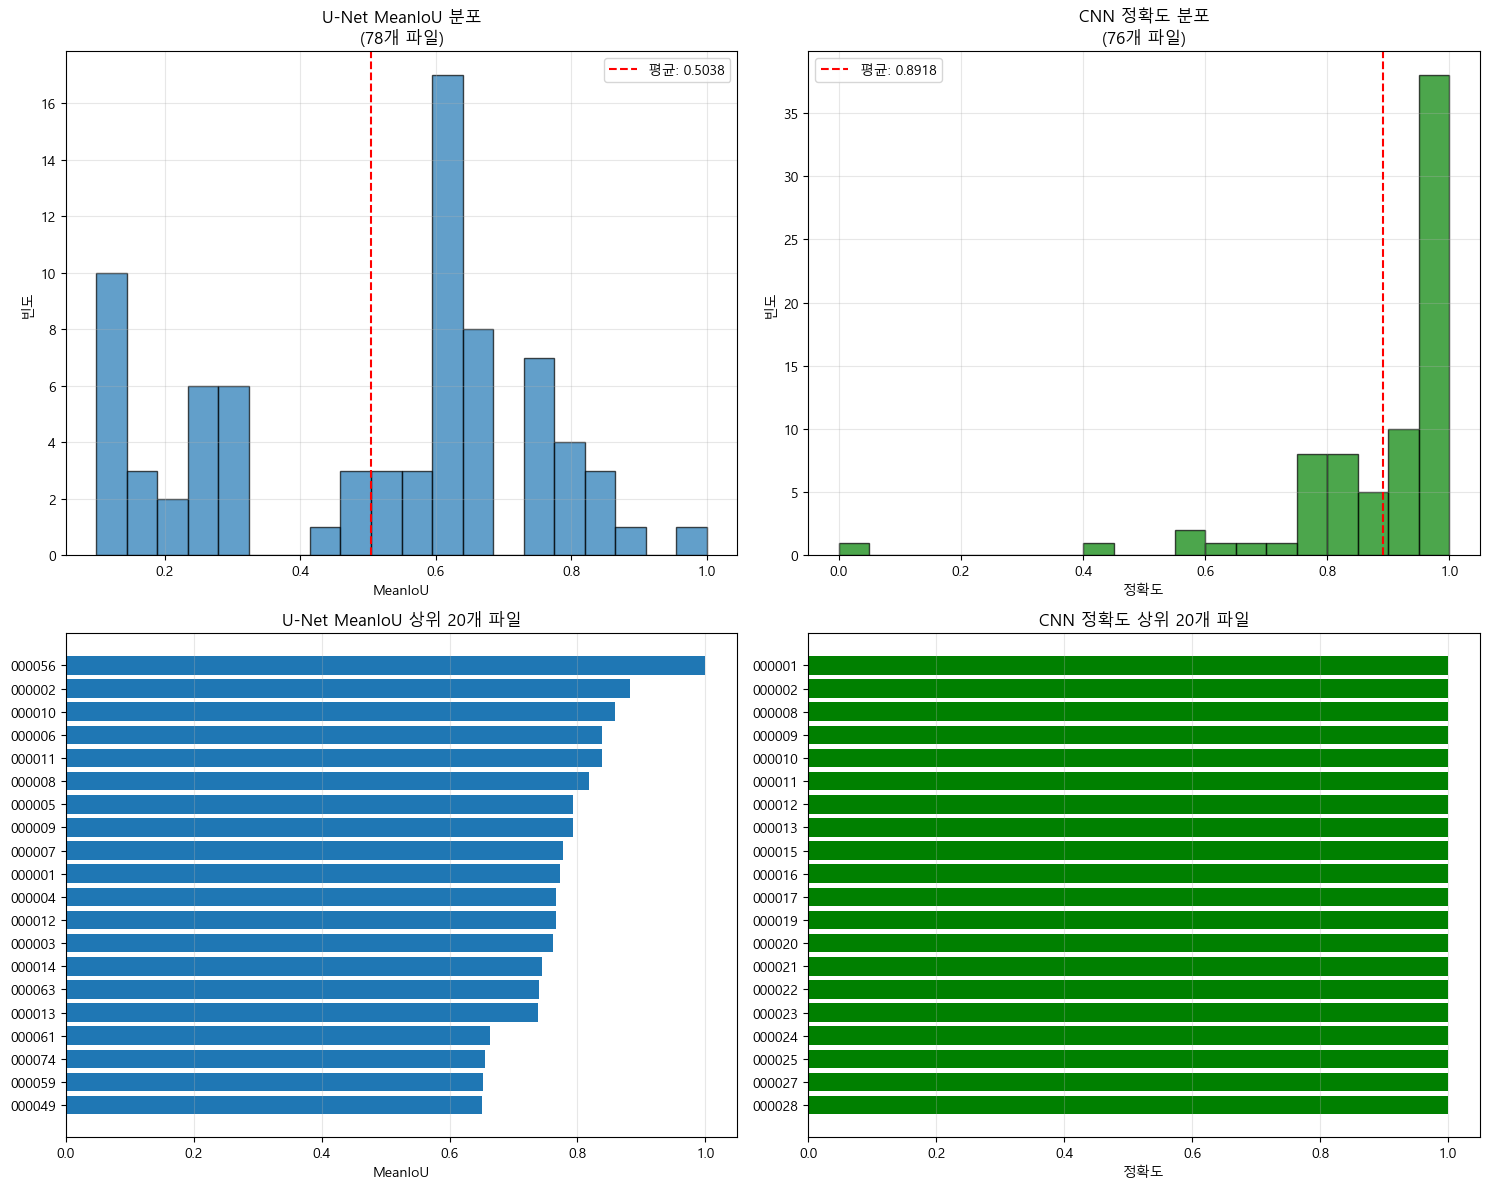

In [ ]:
# Cell 10: 결과 시각화

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# U-Net IoU 분포
if valid_unet_ious:
    axes[0, 0].hist(valid_unet_ious, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(np.mean(valid_unet_ious), color='red', linestyle='--', 
                       label=f'평균: {np.mean(valid_unet_ious):.4f}')
    axes[0, 0].set_xlabel('MeanIoU')
    axes[0, 0].set_ylabel('빈도')
    axes[0, 0].set_title(f'U-Net MeanIoU 분포\n({len(valid_unet_ious)}개 파일)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'U-Net 결과 없음', 
                    ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('U-Net MeanIoU 분포')

# CNN 정확도 분포
if valid_cnn_accuracies:
    axes[0, 1].hist(valid_cnn_accuracies, bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].axvline(np.mean(valid_cnn_accuracies), color='red', linestyle='--',
                       label=f'평균: {np.mean(valid_cnn_accuracies):.4f}')
    axes[0, 1].set_xlabel('정확도')
    axes[0, 1].set_ylabel('빈도')
    axes[0, 1].set_title(f'CNN 정확도 분포\n({len(valid_cnn_accuracies)}개 파일)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'CNN 결과 없음',
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('CNN 정확도 분포')

# U-Net 파일별 IoU (상위 20개)
if valid_unet_ious and 'unet_results' in locals():
    # 파일별 IoU 정렬
    file_iou_pairs = [(file, iou) for file, iou in zip(unet_results['files'], unet_results['ious']) 
                      if iou is not None]
    file_iou_pairs.sort(key=lambda x: x[1], reverse=True)
    top_files = file_iou_pairs[:20]
    
    files = [f[0] for f in top_files]
    ious = [f[1] for f in top_files]
    
    axes[1, 0].barh(range(len(files)), ious)
    axes[1, 0].set_yticks(range(len(files)))
    axes[1, 0].set_yticklabels(files)
    axes[1, 0].set_xlabel('MeanIoU')
    axes[1, 0].set_title('U-Net MeanIoU 상위 20개 파일')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    axes[1, 0].invert_yaxis()
else:
    axes[1, 0].text(0.5, 0.5, 'U-Net 결과 없음',
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('U-Net MeanIoU 상위 파일')

# CNN 파일별 정확도 (상위 20개)
if valid_cnn_accuracies and 'cnn_results' in locals():
    # 파일별 정확도 정렬
    file_acc_pairs = [(file, acc) for file, acc in zip(cnn_results['files'], cnn_results['accuracies'])
                      if acc is not None]
    file_acc_pairs.sort(key=lambda x: x[1], reverse=True)
    top_files = file_acc_pairs[:20]
    
    files = [f[0] for f in top_files]
    accs = [f[1] for f in top_files]
    
    axes[1, 1].barh(range(len(files)), accs, color='green')
    axes[1, 1].set_yticks(range(len(files)))
    axes[1, 1].set_yticklabels(files)
    axes[1, 1].set_xlabel('정확도')
    axes[1, 1].set_title('CNN 정확도 상위 20개 파일')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    axes[1, 1].invert_yaxis()
else:
    axes[1, 1].text(0.5, 0.5, 'CNN 결과 없음',
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('CNN 정확도 상위 파일')

plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / 'test_results_comparison.png', dpi=150, bbox_inches='tight')
print(f"시각화 결과가 {OUTPUT_DIR}/test_results_comparison.png에 저장되었습니다.")
plt.show()


In [ ]:
# Cell 11: 결과를 JSON 파일로 저장

print("=" * 80)
print("결과 저장 중...")
print("=" * 80)

# 출력 디렉터리 생성
output_path = Path(OUTPUT_DIR)
output_path.mkdir(parents=True, exist_ok=True)

# 결과 요약 생성
results_summary = {
    'test_data_dir': str(TEST_DATA_DIR),
    'unet_model': str(UNET_MODEL_PATH) if 'UNET_MODEL_PATH' in locals() else None,
    'cnn_model': str(CNN_MODEL_PATH) if 'CNN_MODEL_PATH' in locals() else None,
    'total_files': len(test_files) if 'test_files' in locals() else 0,
    'pipeline_mode': True,  # 파이프라인 방식 사용
    'detected_defect_files_count': len(detected_defect_files) if 'detected_defect_files' in locals() else 0,
    'unet_results': {
        'mean_iou': float(np.mean(valid_unet_ious)) if valid_unet_ious else None,
        'std_iou': float(np.std(valid_unet_ious)) if valid_unet_ious else None,
        'max_iou': float(np.max(valid_unet_ious)) if valid_unet_ious else None,
        'min_iou': float(np.min(valid_unet_ious)) if valid_unet_ious else None,
        'successful_files': len(valid_unet_ious),
        'defect_detected_files': len(detected_defect_files) if 'detected_defect_files' in locals() else 0,
    } if 'valid_unet_ious' in locals() and valid_unet_ious else None,
    'cnn_results': {
        'mean_accuracy': float(np.mean(valid_cnn_accuracies)) if valid_cnn_accuracies else None,
        'std_accuracy': float(np.std(valid_cnn_accuracies)) if valid_cnn_accuracies else None,
        'max_accuracy': float(np.max(valid_cnn_accuracies)) if valid_cnn_accuracies else None,
        'min_accuracy': float(np.min(valid_cnn_accuracies)) if valid_cnn_accuracies else None,
        'total_patches': int(sum(cnn_results['patch_counts'])) if 'cnn_results' in locals() else 0,
        'successful_files': len(valid_cnn_accuracies),
        'processed_files_count': len(detected_defect_files) if 'detected_defect_files' in locals() else 0,
    } if 'valid_cnn_accuracies' in locals() and valid_cnn_accuracies else None,
    'per_file_results': []
}

# 파일별 상세 결과 추가
if 'unet_results' in locals() and 'cnn_results' in locals():
    # 파일 이름 기준으로 병합
    all_files_in_results = set(unet_results.get('files', []) + cnn_results.get('files', []))
    
    for file_name in sorted(all_files_in_results):
        file_result = {
            'file': file_name,
            'unet_iou': None,
            'cnn_accuracy': None,
            'cnn_patch_count': 0
        }
        
        # U-Net 결과 찾기
        if file_name in unet_results.get('files', []):
            idx = unet_results['files'].index(file_name)
            if idx < len(unet_results.get('ious', [])):
                file_result['unet_iou'] = float(unet_results['ious'][idx]) if unet_results['ious'][idx] is not None else None
            if idx < len(unet_results.get('defect_detected', [])):
                file_result['unet_defect_detected'] = bool(unet_results['defect_detected'][idx])
        
        # CNN 결과 찾기
        if file_name in cnn_results.get('files', []):
            idx = cnn_results['files'].index(file_name)
            if idx < len(cnn_results.get('accuracies', [])):
                file_result['cnn_accuracy'] = float(cnn_results['accuracies'][idx]) if cnn_results['accuracies'][idx] is not None else None
            if idx < len(cnn_results.get('patch_counts', [])):
                file_result['cnn_patch_count'] = int(cnn_results['patch_counts'][idx])
        
        results_summary['per_file_results'].append(file_result)

# JSON 파일로 저장
results_file = output_path / 'test_results_summary.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print(f"\n결과가 {results_file}에 저장되었습니다.")

# 간단한 요약 출력
print("\n" + "=" * 80)
print("저장된 결과 요약")
print("=" * 80)
print(f"테스트 데이터: {TEST_DATA_DIR}")
print(f"총 파일 수: {len(test_files) if 'test_files' in locals() else 0}")

if results_summary['unet_results']:
    print(f"\nU-Net:")
    print(f"  평균 MeanIoU: {results_summary['unet_results']['mean_iou']:.4f}")
    print(f"  성공한 파일: {results_summary['unet_results']['successful_files']}개")
    print(f"  결함 검출된 파일: {results_summary['unet_results']['defect_detected_files']}개")

if results_summary['cnn_results']:
    print(f"\nCNN:")
    print(f"  평균 정확도: {results_summary['cnn_results']['mean_accuracy']:.4f}")
    print(f"  성공한 파일: {results_summary['cnn_results']['successful_files']}개")
    print(f"  처리한 파일 (U-Net이 검출한 파일): {results_summary['cnn_results']['processed_files_count']}개")
    print(f"  총 결함 패치: {results_summary['cnn_results']['total_patches']}개")

print(f"\n파이프라인 방식:")
print(f"  - U-Net이 결함을 검출한 {results_summary['detected_defect_files_count']}개 파일만 CNN으로 전달되었습니다.")

print("=" * 80)


결과 저장 중...

결과가 test_results\test_results_summary.json에 저장되었습니다.

저장된 결과 요약
테스트 데이터: data_test/
총 파일 수: 78

U-Net:
  평균 MeanIoU: 0.5038
  성공한 파일: 78개
  결함 검출된 파일: 77개

CNN:
  평균 정확도: 0.8918
  성공한 파일: 76개
  처리한 파일 (U-Net이 검출한 파일): 77개
  총 결함 패치: 981개

파이프라인 방식:
  - U-Net이 결함을 검출한 77개 파일만 CNN으로 전달되었습니다.
